## Fetch and Display NYSE Stock Data

### yfinance module
nyse 종목

In [1]:
# _tsa_00.py
# nyse stock

# 코랩 추가.
!pip install yfinance

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


### Tickers and close prices

In [2]:
# import pandas as pd
# import yfinance as yf

# 종목 리스트 한 번에 가져오는 아이디어.
# 1. 나스닥 주요 상위 종목 티커 리스트
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META",
           "GOOGL", "TSLA", "AVGO", "COST", "NFLX",
           "SKHY", "MU", "AMD", "ASML", "TSM",
           "INTC"]
stock_data = []

# 2. 각 종목의 세부 정보 가져오기
for tckr in tickers:
    stock = yf.Ticker(tckr)
    info = stock.info

    stock_data.append({
        "티커": tckr,
        "기업명": info.get("longName", "N/A"),
        "섹터": info.get("sector", "N/A"),
        "현재가($)": info.get("currentPrice", "N/A"),
        "시가총액($)": f"{info.get('marketCap', 0):,}"
    })

# 3. 데이터프레임 변환 및 출력
df_tckr = pd.DataFrame(stock_data)
print(df_tckr)

# 티커에 대한 가격, 볼륨 데이터, k 년 자료 가져오기
df_dat = yf.download(tickers, period='1y', auto_adjust=True)
df_dat.info()   # ticker마다 close, open, volume 등

# 다운 자료 중 종가 추출
df_dat_cls = df_dat['Close'].copy()
df_dat_cls

       티커                                                기업명  \
0    AAPL                                         Apple Inc.   
1    MSFT                              Microsoft Corporation   
2    NVDA                                 NVIDIA Corporation   
3    AMZN                                   Amazon.com, Inc.   
4    META                               Meta Platforms, Inc.   
5   GOOGL                                      Alphabet Inc.   
6    TSLA                                        Tesla, Inc.   
7    AVGO                                      Broadcom Inc.   
8    COST                       Costco Wholesale Corporation   
9    NFLX                                      Netflix, Inc.   
10   SKHY                                      SK hynix Inc.   
11     MU                            Micron Technology, Inc.   
12    AMD                       Advanced Micro Devices, Inc.   
13   ASML                                  ASML Holding N.V.   
14    TSM  Taiwan Semiconductor Manufact

[                       0%                       ]

[******                12%                       ]  2 of 16 completed

[*********             19%                       ]  3 of 16 completed

[************          25%                       ]  4 of 16 completed

...

[**********************88%*****************      ]  14 of 16 completed

[**********************94%********************   ]  15 of 16 completed

[*********************100%***********************]  16 of 16 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-22 to 2026-09-21
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    251 non-null    float64
 1   (Close, AMD)     251 non-null    float64
 2   (Close, AMZN)    251 non-null    float64
 3   (Close, ASML)    251 non-null    float64
 4   (Close, AVGO)    251 non-null    float64
 5   (Close, COST)    251 non-null    float64
 6   (Close, GOOGL)   251 non-null    float64
 7   (Close, INTC)    251 non-null    float64
 8   (Close, META)    251 non-null    float64
 9   (Close, MSFT)    251 non-null    float64
 10  (Close, MU)      251 non-null    float64
 11  (Close, NFLX)    251 non-null    float64
 12  (Close, NVDA)    251 non-null    float64
 13  (Close, SKHY)    51 non-null     float64
 14  (Close, TSLA)    251 non-null    float64
 15  (Close, TSM)     251 non-null    float64
 16  (High, AAPL)     251 non-null    float64
 1

Ticker,AAPL,AMD,AMZN,ASML,AVGO,COST,GOOGL,INTC,META,MSFT,MU,NFLX,NVDA,SKHY,TSLA,TSM
Date,,,,,,,,,,,,,,,,
2025-09-22,255.137512,159.789993,227.630005,951.532532,336.289581,937.788452,251.874954,28.760000,762.573303,510.251862,164.356201,122.737000,183.171158,NaN,434.209991,269.774780
2025-09-23,253.493607,160.899994,220.710007,957.205200,336.438477,938.126404,251.007217,29.340000,752.846313,505.074432,166.143326,121.847000,178.003525,NaN,425.850006,279.749207
2025-09-24,251.381393,160.880005,220.210007,940.743774,336.805756,939.786743,246.498932,31.219999,758.088501,505.986877,161.450882,120.394997,176.547028,NaN,442.790009,277.770172
2025-09-25,255.924606,161.270004,218.149994,943.336609,333.619446,937.838135,245.152451,33.990002,746.378174,502.892365,156.578690,120.823997,177.265305,NaN,423.390015,273.762604
2025-09-26,254.519806,159.460007,219.779999,945.293762,332.061035,910.636902,245.900482,35.500000,741.235718,507.286194,157.017990,121.060997,177.764099,NaN,440.399994,270.497162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-15,331.339996,504.200012,248.419998,1591.479980,338.653320,901.349976,344.980011,97.139999,669.711487,497.119995,927.599976,77.900002,212.169998,174.830002,356.579987,412.643005
2026-09-16,332.410004,512.500000,245.960007,1602.219971,338.892914,893.739990,342.869995,101.050003,672.779053,490.299988,926.549988,76.410004,213.899994,174.869995,358.079987,417.720001
2026-09-17,337.000000,545.090027,251.190002,1629.670044,346.668732,893.929993,347.329987,108.800003,681.771973,497.750000,977.500000,75.309998,219.339996,182.990005,366.200012,430.260010


### subplots, line chart, prices, returns

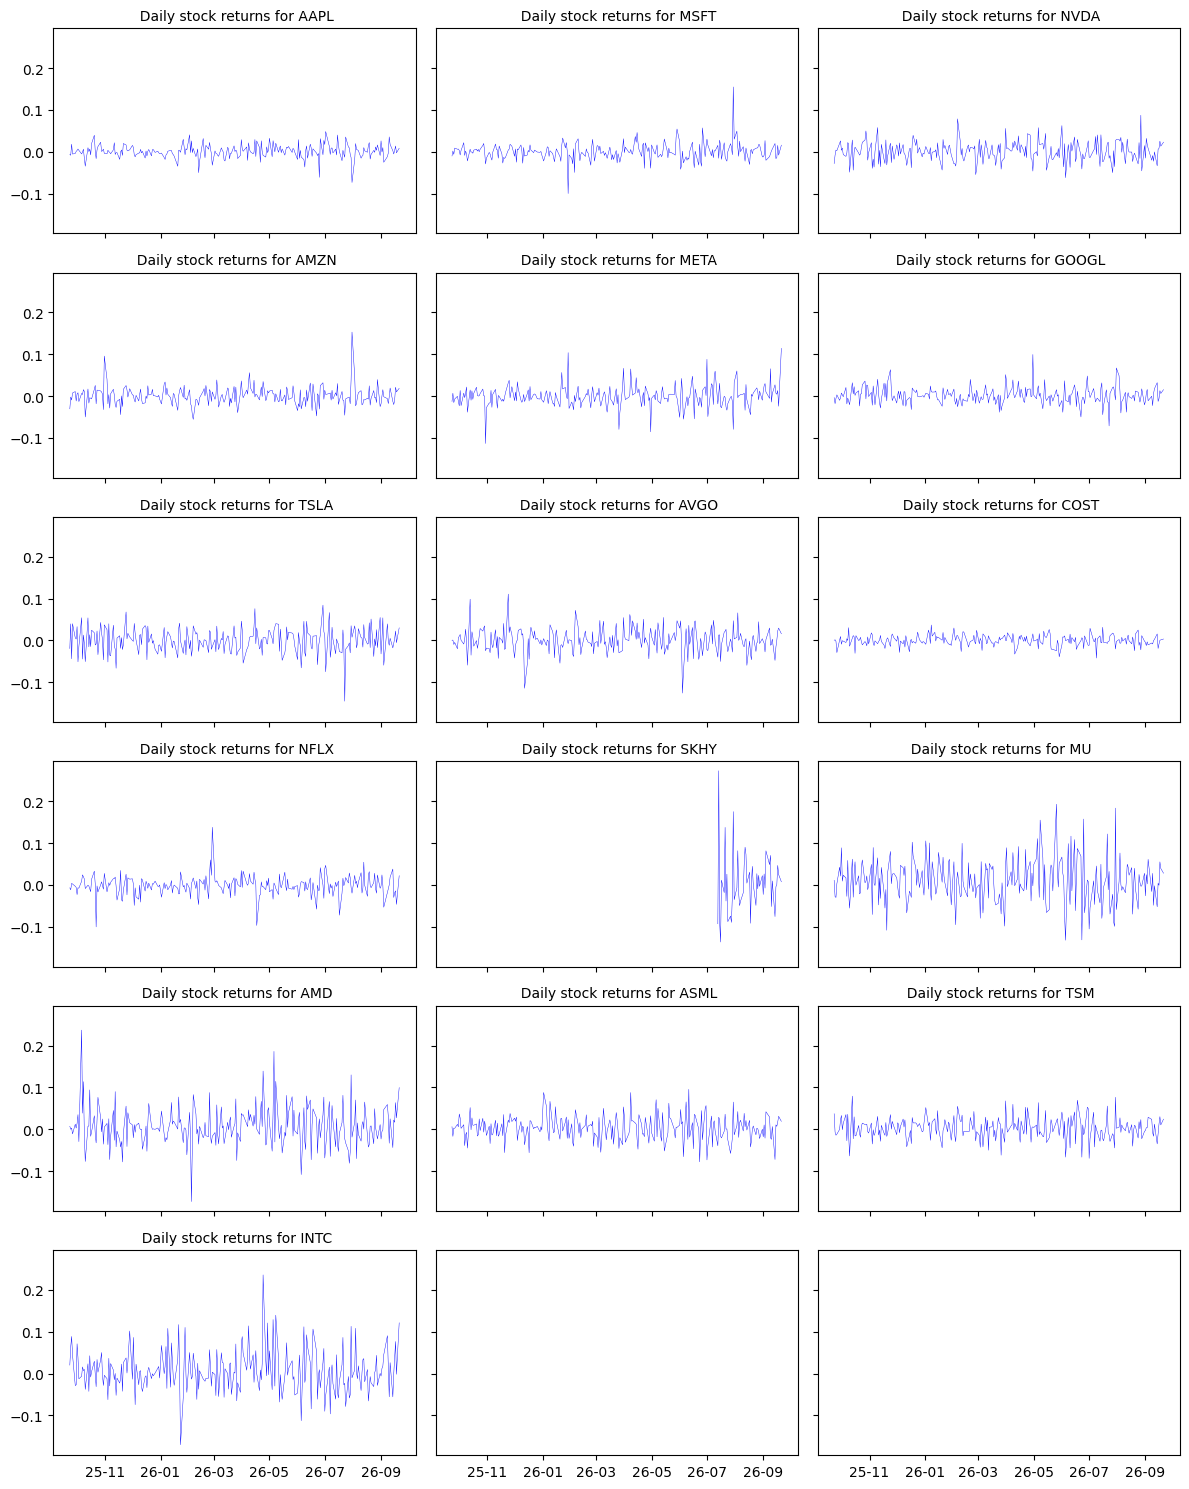

In [3]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

n_plot = len(tickers)
sub_c = 3
sub_r = int(np.ceil(n_plot/sub_c))

fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*4, sub_r*2.5),
                         sharex=True,
                         sharey=True
                         )

for ax, ticker in zip(axes.flat, tickers) :
  ax.plot(yymmdd,
          df_dat_cls[ticker].pct_change(fill_method=None),
          color='blue',
          linewidth=0.3
          )  # 여기 ticker는 이미 "AAPL"처럼 인식, 앞에서.
  ax.set_title(f"  Daily stock returns for {ticker} ", fontsize=10)
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.tight_layout()
plt.show()

### subplots, histograms, daily returns

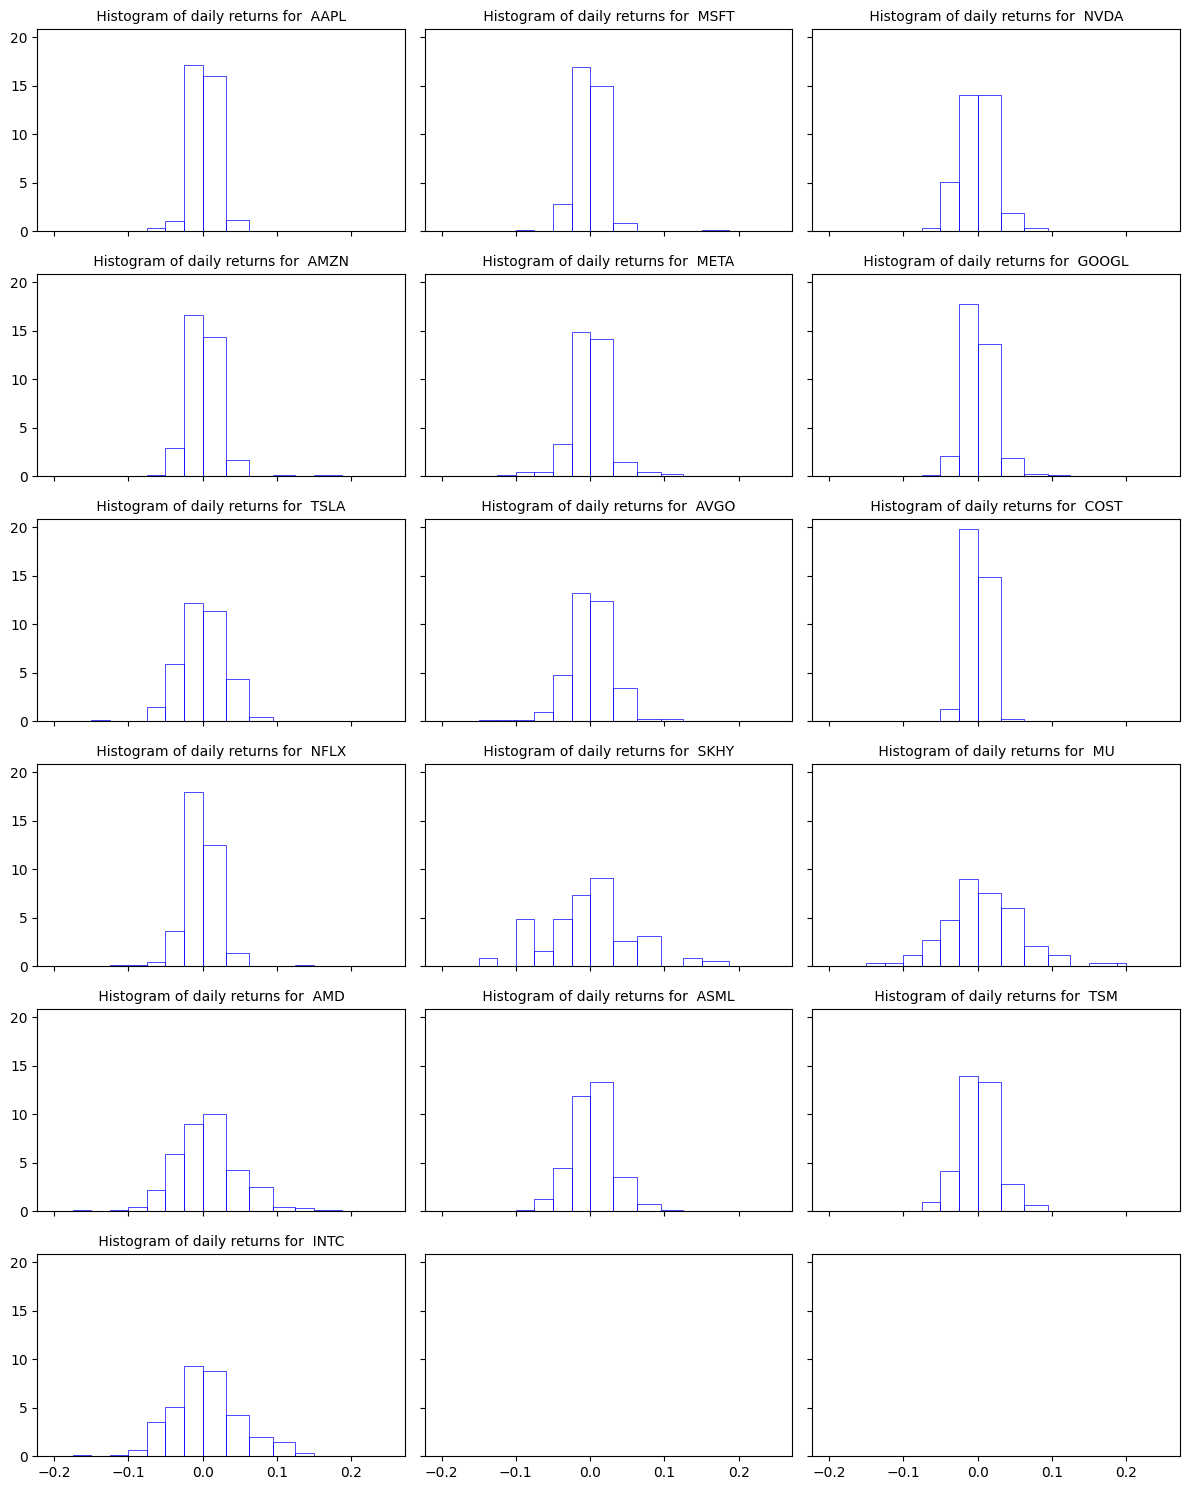

In [4]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
#yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
#yymmdd = pd.to_datetime( yymmdd )

n_plot = len(tickers)
sub_c = 3
sub_r = int(np.ceil(n_plot/sub_c))

b_class = [-0.2, -0.175, -0.15, -0.125, -0.1, -0.075, -0.05,-0.025, 0.0, 0.03125, 0.0625, 0.095, 0.125, 0.15, 0.1875, 0.2, 0.25]

fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*4, sub_r*2.5),
                         sharex=True,
                         sharey=True
                         )
for ax, ticker in zip(axes.flat, tickers) :
  ax.hist(df_dat_cls[ticker].pct_change(fill_method=None), # 여기 ticker는 이미 "AAPL"처럼 인식, 앞에서.
          color='blue',
          linewidth=0.5,
          bins = b_class,       # 11처럼 갯수로 지정, 혹은 계급 구간 제시,
          facecolor='None',
          edgecolor='blue',
          density=True
          )
  ax.set_title(f" Histogram of daily returns for  {ticker} ", fontsize=10)
plt.tight_layout()
plt.show()

### two tickers, prices
뭔가 간단하게

In [5]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

tic_1 = 'NFLX'
tic_2 = 'GOOGL'
stck_prc_1= df_dat_cls[tic_1]
stck_prc_2 = df_dat_cls[tic_2]


#### daily stock returns

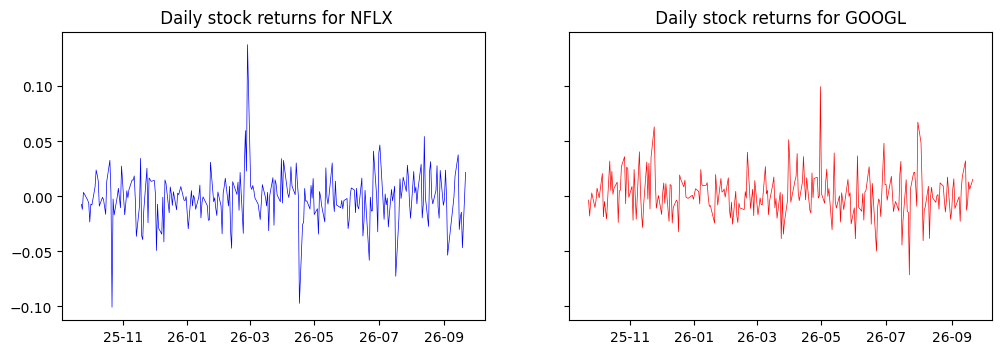

In [6]:
# 나란히 차트 2개. 1행, 2열.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16*0.75, 10*0.75/2), sharex=True, sharey=True )
axes[0].plot(yymmdd, stck_prc_1.pct_change(fill_method=None), color='blue', linewidth=0.5)
axes[1].plot(yymmdd, stck_prc_2.pct_change(fill_method=None), color='red', linewidth=0.5)

axes[0].set_title(f" Daily stock returns for {tic_1}")
axes[1].set_title(f" Daily stock returns for {tic_2} ")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))


#### distibutions in one chart

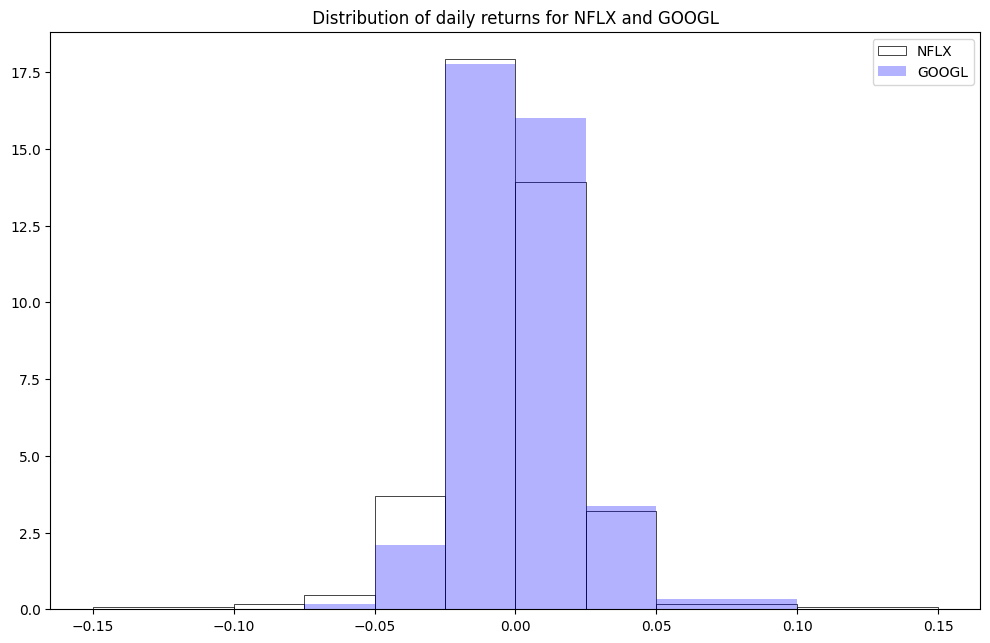

In [7]:
# 차트 여러 개, 화면 1개.
b_class = [-0.15, -0.1, -0.075, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.15 ]
plt.figure(figsize=(12, 7.5))
plt.hist(stck_prc_1.pct_change(fill_method=None),
         color='blue',
         linewidth=0.51,
         bins = b_class, # 11,
         facecolor='None',
         edgecolor='black',
         density=True,
         label = f"{tic_1}"
         )
plt.hist(stck_prc_2.pct_change(fill_method=None),
         color='blue',
         linewidth=1,
         bins = b_class, # 11,
         facecolor='blue',
         edgecolor='None',
         density=True,
         #linestyle='--'
         label = f"{tic_2}",
         alpha = 0.3
         )
plt.title(f" Distribution of daily returns for {tic_1} and {tic_2} ")
plt.legend()
plt.show()